In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix
)

from imblearn.over_sampling import SMOTENC

**Tahap 1: Masukkan Data**

In [7]:
file_path = "DES 2025- JUNI 2026_EJP.xlsx"

df = pd.read_excel(
    file_path,
    sheet_name=0,
    header=1
)

print("Jumlah data:", len(df))
print(df.head())

Jumlah data: 1303
    NO  Part ID                          Description  Qty  Unit  \
0    1  44-FG27  POWER CABLE, FLAT AWG#2, GALVANIZED    1  REEL   
1    2  44-FG27  POWER CABLE, FLAT AWG#2, GALVANIZED    1  REEL   
2    3  44-FG17  POWER CABLE, FLAT AWG#1, GALVANIZED    1  REEL   
3  NaN      NaN                                  NaN  NaN   NaN   
4    4  44-FG27  POWER CABLE, FLAT AWG#2, GALVANIZED    1  REEL   

               WO Date              WO No.              MR Date  \
0  2025-12-01 00:00:00  WO/DR/2025/12/0002  2025-12-02 00:00:00   
1  2025-12-01 00:00:00  WO/DR/2025/12/0003  2025-12-01 00:00:00   
2  2025-12-01 00:00:00  WO/DR/2025/12/0004  2025-12-02 00:00:00   
3                  NaN  WO/DR/2025/12/0004  2025-12-02 00:00:00   
4  2025-12-01 00:00:00  WO/DR/2025/12/0005  2025-12-02 00:00:00   

                   MR No.       Tgl Penyerahan        No. Penyerahan  Status  
0  MR-P/DR-A/2025/12/0008  2025-12-02 00:00:00  DN-M/DR/2025/12/0012  CLOSED  
1  MR-P/DR-A/2025/

**Tahap 2: Data Cleaning (Noise, Outlier, dan Duplikat)**

In [8]:
# Konversi tanggal
df["WO Date"] = pd.to_datetime(
    df["WO Date"],
    errors="coerce"
)

df["MR Date"] = pd.to_datetime(
    df["MR Date"],
    errors="coerce"
)

df["Tgl Penyerahan"] = pd.to_datetime(
    df["Tgl Penyerahan"],
    errors="coerce"
)

# Ambil periode Desember 2025 - Juni 2026
df = df[
    (df["MR Date"] >= "2025-12-01") &
    (df["MR Date"] < "2026-07-01")
].copy()

# Hapus data yang tidak memiliki informasi utama
df = df.dropna(
    subset=[
        "Part ID",
        "MR Date",
        "Tgl Penyerahan"
    ]
)

# Hapus duplikat
df = df.drop_duplicates()

# Konversi Qty
df["Qty"] = pd.to_numeric(
    df["Qty"],
    errors="coerce"
)

# Hapus Qty yang tidak valid
df = df.dropna(
    subset=["Qty"]
)

# Hitung lead time
df["Rentang_Hari"] = (
    df["Tgl Penyerahan"] -
    df["MR Date"]
).dt.days

# Hanya mempertahankan lead time yang valid
df = df[
    df["Rentang_Hari"] >= 0
].reset_index(drop=True)

print("Jumlah data setelah cleaning:", len(df))

Jumlah data setelah cleaning: 894


**Tahap 3: Cek outlier**

In [9]:
Q1 = df["Rentang_Hari"].quantile(0.25)
Q3 = df["Rentang_Hari"].quantile(0.75)

IQR = Q3 - Q1

batas_bawah = Q1 - (1.5 * IQR)
batas_atas = Q3 + (1.5 * IQR)

outlier = df[
    (df["Rentang_Hari"] < batas_bawah) |
    (df["Rentang_Hari"] > batas_atas)
]

print("Jumlah outlier:", len(outlier))
print("Batas bawah:", batas_bawah)
print("Batas atas:", batas_atas)

Jumlah outlier: 106
Batas bawah: -1.5
Batas atas: 2.5


**Tahap 4: Matrix evaluasi atribut (EDA)**

In [10]:
candidate_features = [
    "Part ID",
    "Description",
    "Qty",
    "Unit",
    "WO_MR_Days",
    "MR_Month",
    "MR_DayOfWeek"
]

In [11]:
df["WO_MR_Days"] = (
    df["MR Date"] -
    df["WO Date"]
).dt.days

df["MR_Month"] = df["MR Date"].dt.month

df["MR_DayOfWeek"] = (
    df["MR Date"].dt.dayofweek
)

**Tahap 5: EDA**

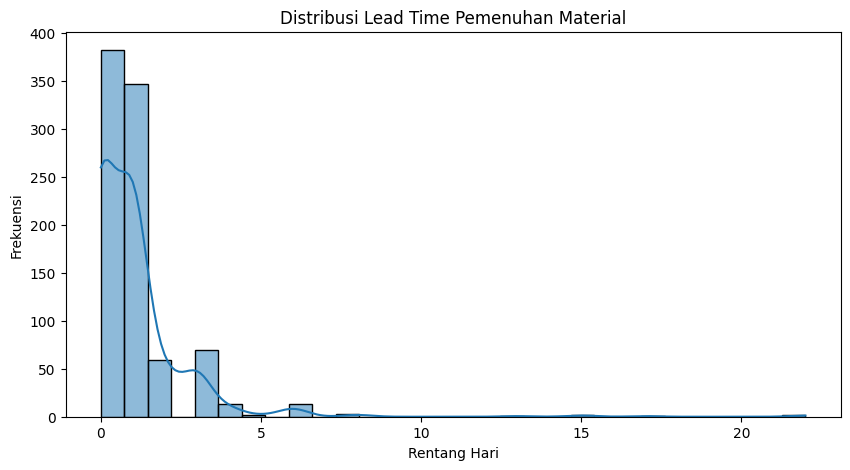

In [12]:
plt.figure(figsize=(10,5))

sns.histplot(
    df["Rentang_Hari"],
    bins=30,
    kde=True
)

plt.title(
    "Distribusi Lead Time Pemenuhan Material"
)

plt.xlabel("Rentang Hari")
plt.ylabel("Frekuensi")

plt.show()

In [13]:
df["Bulan_MR"] = (
    df["MR Date"]
    .dt.to_period("M")
    .astype(str)
)

print(
    df.groupby("Bulan_MR")
      .size()
)

Bulan_MR
2025-12    162
2026-01      6
2026-02     91
2026-03    168
2026-04    136
2026-05    182
2026-06    149
dtype: int64


**Pelabelan**

In [14]:
def kategori_lead_time(hari):

    if hari <= 1:
        return "Cepat"

    elif hari <= 3:
        return "Standar"

    else:
        return "Lambat"


df["Kategori_LeadTime"] = (
    df["Rentang_Hari"]
    .apply(kategori_lead_time)
)

In [15]:
print(
    df["Kategori_LeadTime"]
    .value_counts()
)

Kategori_LeadTime
Cepat      729
Standar    128
Lambat      37
Name: count, dtype: int64


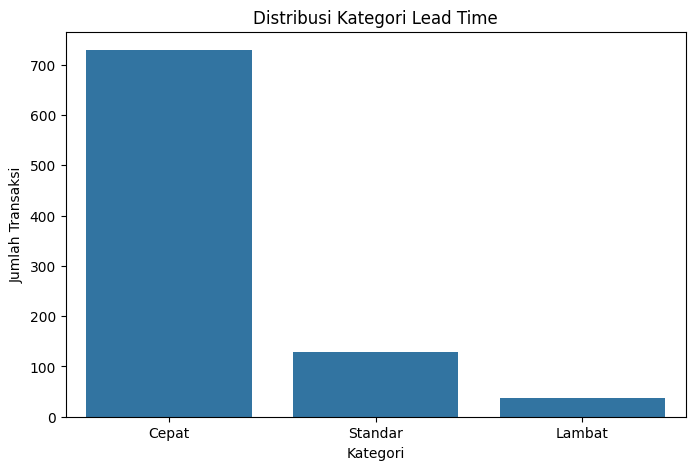

In [16]:
urutan = [
    "Cepat",
    "Standar",
    "Lambat"
]

kategori = (
    df["Kategori_LeadTime"]
    .value_counts()
    .reindex(urutan)
)

plt.figure(figsize=(8,5))

sns.barplot(
    x=kategori.index,
    y=kategori.values
)

plt.title(
    "Distribusi Kategori Lead Time"
)

plt.xlabel("Kategori")
plt.ylabel("Jumlah Transaksi")

plt.show()

In [17]:
features = [
    "Part ID",
    "Unit",
    "WO_MR_Days",
    "MR_Month",
    "MR_DayOfWeek"
]

X = df[features]

y = df["Kategori_LeadTime"]

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Data training:", len(X_train))
print("Data testing :", len(X_test))

Data training: 715
Data testing : 179


In [20]:
categorical_features = [
    "Part ID",
    "Unit"
]

numeric_features = [
    "WO_MR_Days",
    "MR_Month",
    "MR_DayOfWeek"
]

In [21]:
from sklearn.preprocessing import OrdinalEncoder
from sklearn.impute import SimpleImputer

encoder = OrdinalEncoder(
    handle_unknown="use_encoded_value",
    unknown_value=-1
)

X_train_cat = encoder.fit_transform(
    X_train[categorical_features]
)

X_test_cat = encoder.transform(
    X_test[categorical_features]
)

imputer = SimpleImputer(
    strategy="median"
)

X_train_num = imputer.fit_transform(
    X_train[numeric_features]
)

X_test_num = imputer.transform(
    X_test[numeric_features]
)

In [22]:
X_train_encoded = np.column_stack([
    X_train_cat,
    X_train_num
])

X_test_encoded = np.column_stack([
    X_test_cat,
    X_test_num
])

In [23]:
smote = SMOTENC(
    categorical_features=[0, 1],
    random_state=42,
    k_neighbors=5
)

X_train_smote, y_train_smote = (
    smote.fit_resample(
        X_train_encoded,
        y_train
    )
)

In [24]:
print("Sebelum SMOTENC:")
print(y_train.value_counts())

print("\nSesudah SMOTENC:")
print(pd.Series(y_train_smote).value_counts())

Sebelum SMOTENC:
Kategori_LeadTime
Cepat      583
Standar    102
Lambat      30
Name: count, dtype: int64

Sesudah SMOTENC:
Kategori_LeadTime
Standar    583
Cepat      583
Lambat     583
Name: count, dtype: int64


In [25]:
rf_classifier = RandomForestClassifier(
    n_estimators=500,
    random_state=42,
    n_jobs=-1
)

rf_classifier.fit(
    X_train_smote,
    y_train_smote
)

RandomForestClassifier(n_estimators=500, n_jobs=-1, random_state=42)

In [26]:
y_pred = rf_classifier.predict(
    X_test_encoded
)

In [27]:
accuracy = accuracy_score(
    y_test,
    y_pred
)

precision = precision_score(
    y_test,
    y_pred,
    average="macro",
    zero_division=0
)

recall = recall_score(
    y_test,
    y_pred,
    average="macro",
    zero_division=0
)

f1 = f1_score(
    y_test,
    y_pred,
    average="macro",
    zero_division=0
)

balanced_acc = balanced_accuracy_score(
    y_test,
    y_pred
)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1-Score :", f1)
print("Balanced Accuracy:", balanced_acc)

Accuracy : 0.8379888268156425
Precision: 0.57
Recall   : 0.535325405188419
F1-Score : 0.547666650607827
Balanced Accuracy: 0.535325405188419


In [28]:
print(
    classification_report(
        y_test,
        y_pred,
        labels=[
            "Cepat",
            "Standar",
            "Lambat"
        ],
        zero_division=0
    )
)

              precision    recall  f1-score   support

       Cepat       0.90      0.92      0.91       146
     Standar       0.56      0.54      0.55        26
      Lambat       0.25      0.14      0.18         7

    accuracy                           0.84       179
   macro avg       0.57      0.54      0.55       179
weighted avg       0.83      0.84      0.83       179



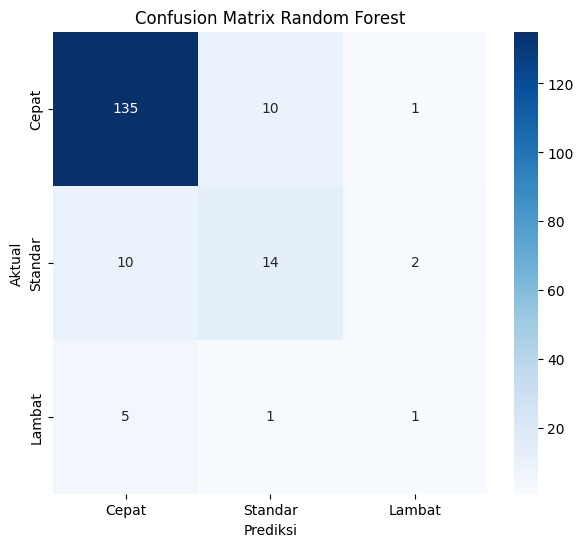

In [29]:
labels = [
    "Cepat",
    "Standar",
    "Lambat"
]

cm = confusion_matrix(
    y_test,
    y_pred,
    labels=labels
)

plt.figure(figsize=(7,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=labels,
    yticklabels=labels
)

plt.title(
    "Confusion Matrix Random Forest"
)

plt.xlabel("Prediksi")
plt.ylabel("Aktual")

plt.show()

In [30]:
y_train_pred = rf_classifier.predict(
    X_train_smote
)

train_accuracy = accuracy_score(
    y_train_smote,
    y_train_pred
)

test_accuracy = accuracy_score(
    y_test,
    y_pred
)

print(
    "Training Accuracy:",
    train_accuracy
)

print(
    "Testing Accuracy:",
    test_accuracy
)

print(
    "Selisih:",
    train_accuracy - test_accuracy
)

Training Accuracy: 0.985134362492853
Testing Accuracy: 0.8379888268156425
Selisih: 0.14714553567721056


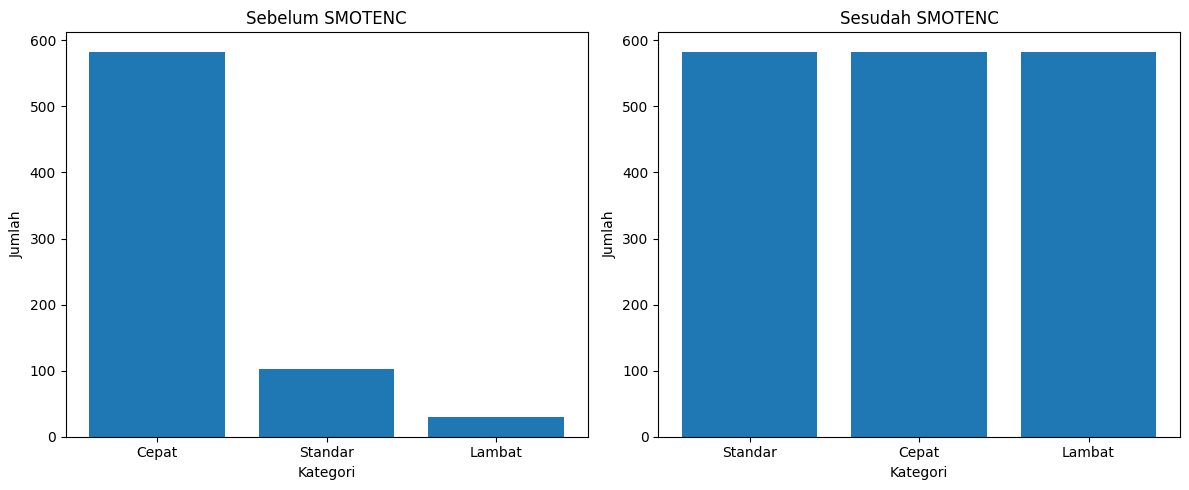

In [31]:
before = pd.Series(y_train).value_counts()

after = pd.Series(y_train_smote).value_counts()

fig, axes = plt.subplots(
    1,
    2,
    figsize=(12,5)
)

axes[0].bar(
    before.index,
    before.values
)

axes[0].set_title(
    "Sebelum SMOTENC"
)

axes[0].set_xlabel(
    "Kategori"
)

axes[0].set_ylabel(
    "Jumlah"
)


axes[1].bar(
    after.index,
    after.values
)

axes[1].set_title(
    "Sesudah SMOTENC"
)

axes[1].set_xlabel(
    "Kategori"
)

axes[1].set_ylabel(
    "Jumlah"
)

plt.tight_layout()

plt.show()